In [55]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Used for data normalization
from sklearn.preprocessing import StandardScaler

# Display plots inside the Jupyter Notebook
%matplotlib inline
# Import libraries required for building the ANN

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
# Import Adam optimizer
from tensorflow.keras.optimizers import Adam

# Libraries for splitting the dataset and evaluating the model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Data Exploration and Preprocessing

In [3]:

# Read the CSV file into a Pandas DataFrame
df = pd.read_csv("sonardataset.csv")

# Display the first five rows
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [4]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 208
Number of columns: 61


In [5]:
#check the data type
print(df.dtypes)

x_1     float64
x_2     float64
x_3     float64
x_4     float64
x_5     float64
         ...   
x_57    float64
x_58    float64
x_59    float64
x_60    float64
Y        object
Length: 61, dtype: object


In [6]:

# Display Complete Dataset Information


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [7]:
# Statistical Summary of Numerical Features


df.describe()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [8]:

# Check for Missing Values


missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
x_1     0
x_2     0
x_3     0
x_4     0
x_5     0
       ..
x_57    0
x_58    0
x_59    0
x_60    0
Y       0
Length: 61, dtype: int64


In [9]:

# Calculate total number of missing values
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
# Check Target/Class Distribution

print(df['Y'].value_counts())

Y
M    111
R     97
Name: count, dtype: int64


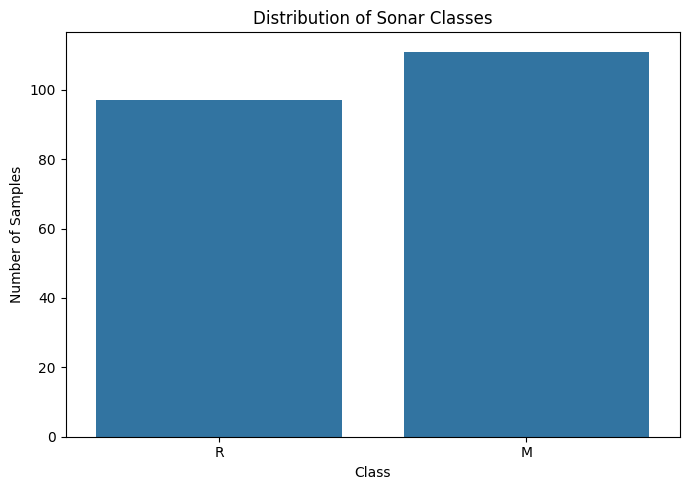

In [12]:
# Visualize Class Distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Y')

plt.title('Distribution of Sonar Classes')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

plt.tight_layout()
plt.show()

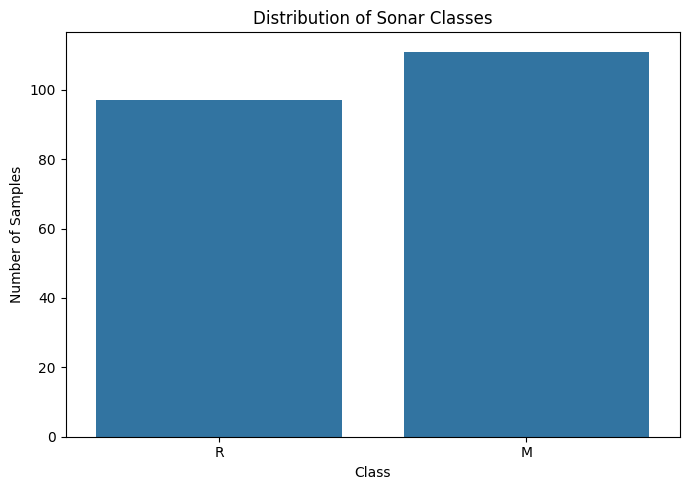

In [13]:

# Visualize Class Distribution


plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Y')

plt.title('Distribution of Sonar Classes')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

plt.tight_layout()
plt.show()

In [14]:

# Separate Input Features and Target Variable


# Select the 60 sonar features
X = df.drop('Y', axis=1)

# Select the target variable
y = df['Y']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (208, 60)
Target shape: (208,)


In [15]:
# Check Feature Ranges

print("Minimum feature value:", X.min().min())
print("Maximum feature value:", X.max().max())

Minimum feature value: 0.0
Maximum feature value: 1.0


In [16]:
# Check Feature Ranges


print("Minimum feature value:", X.min().min())
print("Maximum feature value:", X.max().max())

Minimum feature value: 0.0
Maximum feature value: 1.0


In [17]:
# Display minimum and maximum values for each feature
feature_range = pd.DataFrame({
    'Minimum': X.min(),
    'Maximum': X.max()
})

feature_range.head(10)

,Minimum,Maximum
x_1,0.0015,0.1371
x_2,0.0006,0.2339
x_3,0.0015,0.3059
x_4,0.0058,0.4264
x_5,0.0067,0.4010
x_6,0.0102,0.3823
x_7,0.0033,0.3729
x_8,0.0055,0.4590
x_9,0.0075,0.6828
x_10,0.0113,0.7106


In [18]:

# Normalize / Standardize the Input Features


# Create the StandardScaler object
scaler = StandardScaler()

# Fit the scaler and transform the feature data
X_scaled = scaler.fit_transform(X)

# Convert the normalized NumPy array back to a DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Display the first five normalized records
X_scaled.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
0,-0.399551,-0.040648,-0.026926,-0.715105,0.364456,-0.101253,0.521638,0.297843,1.125272,0.021186,...,0.595283,-1.115432,-0.597604,0.680897,-0.295646,1.481635,1.763784,0.069870,0.171678,-0.658947
1,0.703538,0.421630,1.055618,0.323330,0.777676,2.607217,1.522625,2.510982,1.318325,0.588706,...,-0.297902,-0.522349,-0.256857,-0.843151,0.015503,1.901046,1.070732,-0.472406,-0.444554,-0.419852
2,-0.129229,0.601067,1.723404,1.172176,0.400545,2.093337,1.968770,2.852370,3.232767,3.066105,...,-1.065875,1.017585,0.836373,-0.197833,1.231812,2.827246,4.120162,1.309360,0.252761,0.257582
3,-0.835555,-0.648910,0.481740,-0.719414,-0.987079,-1.149364,-0.193816,-0.084747,-1.000852,-0.610469,...,0.670411,-0.137365,-1.009341,0.557326,-0.111785,-0.161060,-0.488635,-0.549875,-0.639154,1.034640
4,2.050790,0.856537,0.111327,-0.312227,-0.292365,-0.672796,-0.013735,1.317299,1.510531,1.772220,...,-0.039129,-1.073812,-0.753780,-0.060532,0.241793,-1.174638,-0.107456,-0.487900,0.447361,0.576375


In [19]:
# Verify the Standardization


print("Mean of standardized features:")
print(X_scaled.mean().head())

print("\nStandard deviation of standardized features:")
print(X_scaled.std().head())

Mean of standardized features:
x_1    1.708035e-17
x_2    6.832142e-17
x_3   -1.195625e-16
x_4    1.622634e-16
x_5   -1.793437e-16
dtype: float64

Standard deviation of standardized features:
x_1    1.002413
x_2    1.002413
x_3    1.002413
x_4    1.002413
x_5    1.002413
dtype: float64


In [20]:
# Encode Target Classes


# Convert categorical labels into numerical values
y_encoded = y.map({
    'R': 0,   # Rock
    'M': 1    # Mine
})

# Display the first few encoded values
print(y_encoded.head(10))

# Check that all labels were successfully encoded
print("\nUnique encoded classes:")
print(y_encoded.unique())

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Y, dtype: int64

Unique encoded classes:
[0 1]


In [21]:
# Final Check After Preprocessing


print("Final feature shape:", X_scaled.shape)
print("Final target shape:", y_encoded.shape)

print("\nMissing values in features:")
print(X_scaled.isnull().sum().sum())

print("\nMissing values in target:")
print(y_encoded.isnull().sum())

Final feature shape: (208, 60)
Final target shape: (208,)

Missing values in features:
0

Missing values in target:
0


## Task 1 Conclusion

The Sonar dataset contains 208 observations and 60 numerical input
features. The target variable `Y` contains two classes: Mine (`M`) and
Rock (`R`), with 111 and 97 observations respectively.

The dataset was examined for data types, missing values, duplicate
records, descriptive statistics, and class distribution. No missing
values were found, so no missing-value imputation was required.

The 60 input features were separated from the target variable and
standardized using StandardScaler so that the features have comparable
scales. The target labels were encoded numerically, with Rock represented
as 0 and Mine represented as 1.

The resulting preprocessed dataset contains 208 samples, 60 standardized
features, and a binary target variable. This dataset is now ready for
splitting into training and testing sets and building the Artificial
Neural Network model.

# Model Implementation

In [22]:
# Select the 60 numerical sonar features as input variables
X = df.drop('Y', axis=1)

# Select the class label as the target variable
y = df['Y']

# Convert the target labels into numerical values
# Rock is represented by 0
# Mine is represented by 1
y = y.map({
    'R': 0,
    'M': 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (208, 60)
Target shape: (208,)


In [23]:
# Divide the dataset into training and testing sets
#
# test_size=0.20 means 20% of the data will be used for testing
# random_state=42 ensures that we get the same split every time
# stratify=y keeps the Mine and Rock proportions similar
# in both training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the resulting datasets

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (166, 60)
Testing feature shape: (42, 60)
Training target shape: (166,)
Testing target shape: (42,)


In [24]:
# Create the StandardScaler object
scaler = StandardScaler()

# Learn the mean and standard deviation only from the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same transformation learned from the training data
# to transform the test data
X_test_scaled = scaler.transform(X_test)

# Display the shapes after scaling

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (166, 60)
Scaled testing data shape: (42, 60)


In [25]:
# Create a Sequential neural network
model = Sequential()

# Input layer and first hidden layer
# 32 neurons are used in the hidden layer
# ReLU is used as the activation function
# input_shape=(60,) because the dataset has 60 input features

model.add(Dense(
    32,
    activation='relu',
    input_shape=(60,)
))

# Output layer
# One neuron is used because this is a binary classification problem
# Sigmoid converts the output into a probability between 0 and 1

model.add(Dense(
    1,
    activation='sigmoid'
))

# Display the structure of the ANN
model.summary()

C:\Users\BALAJI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Compile the ANN model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [27]:
# Train the neural network
#
# epochs=50 means the complete training dataset is passed
# through the network 50 times
#
# batch_size=16 means the model processes 16 observations
# at a time before updating the weights
#
# validation_split=0.20 reserves 20% of the training data
# for monitoring validation performance during training

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5530 - loss: 0.7047 - val_accuracy: 0.7647 - val_loss: 0.5577
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6894 - loss: 0.6150 - val_accuracy: 0.7941 - val_loss: 0.5308
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7500 - loss: 0.5514 - val_accuracy: 0.7941 - val_loss: 0.4979
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7652 - loss: 0.5057 - val_accuracy: 0.8235 - val_loss: 0.4699
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7955 - loss: 0.4685 - val_accuracy: 0.8235 - val_loss: 0.4492
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8182 - loss: 0.4370 - val_accuracy: 0.8529 - val_loss: 0.4343
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8409 - loss: 0.4118 - val_accuracy: 0.8235 - val_loss: 0.4193
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8561 - loss: 0.3882 - val_accuracy: 0.8235 - val_loss: 0.4081


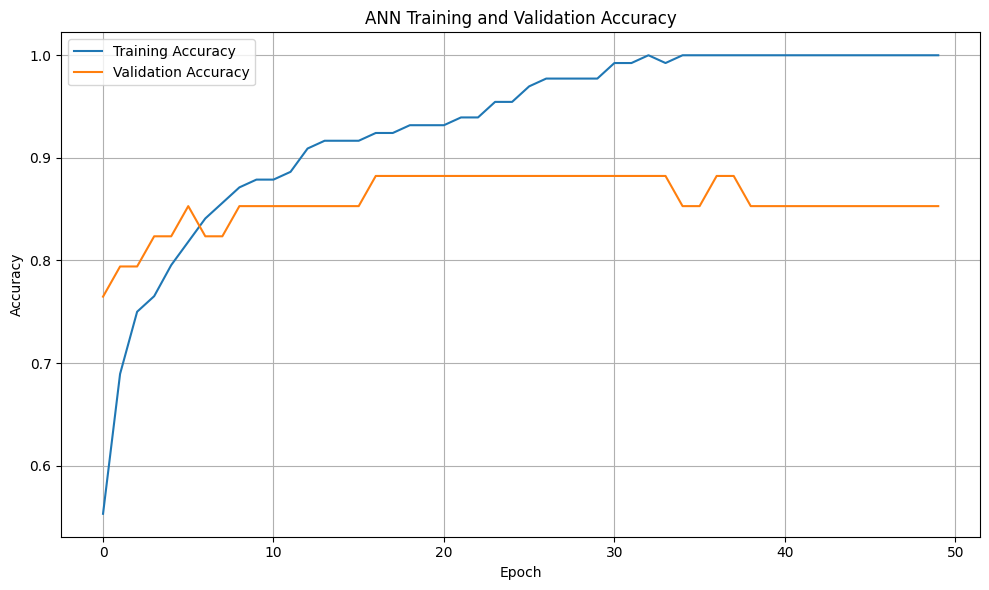

In [29]:
# Plot training and validation accuracy

plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('ANN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

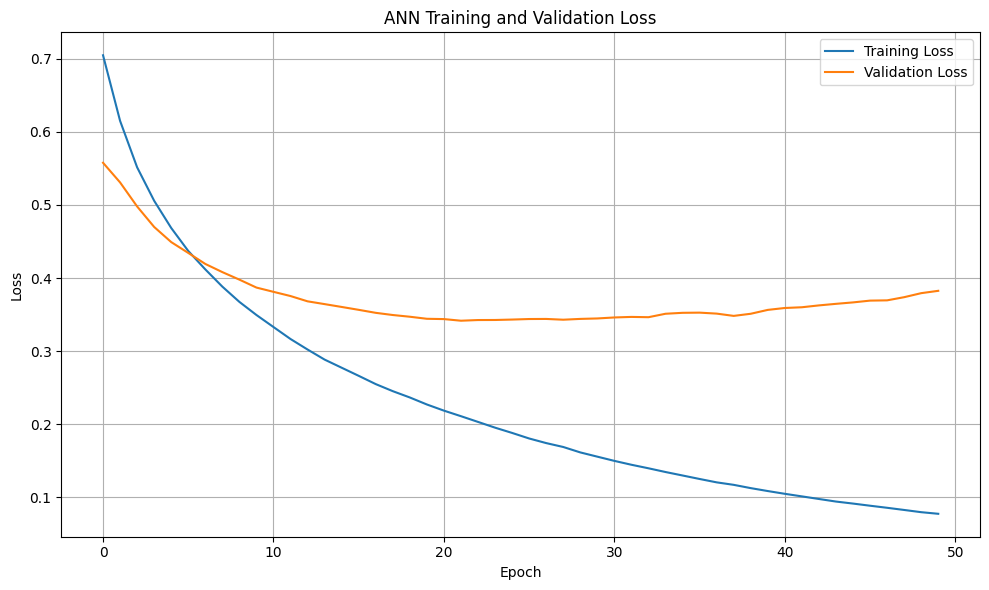

In [30]:
# Plot training and validation loss

plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('ANN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
# Generate probability predictions for the test data

y_pred_probability = model.predict(X_test_scaled)

# Display the first 10 predicted probabilities

print(y_pred_probability[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
[[0.2728617 ]
 [0.7775923 ]
 [0.9855657 ]
 [0.9981664 ]
 [0.00705583]
 [0.9921171 ]
 [0.18173629]
 [0.999906  ]
 [0.00415582]
 [0.04255925]]


In [32]:
# Convert predicted probabilities into class labels
#
# Probability >= 0.5 → Mine → 1
# Probability < 0.5  → Rock → 0

y_pred = (y_pred_probability >= 0.5).astype(int)

# Convert the two-dimensional prediction array into one dimension

y_pred = y_pred.ravel()

print("Predicted classes:")
print(y_pred[:20])

Predicted classes:
[0 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 0 1 1 0]


In [33]:
# Create a comparison table containing
# actual and predicted class values

prediction_comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(prediction_comparison.head(20))

    Actual  Predicted
0        1          0
1        1          1
2        1          1
3        1          1
4        0          0
5        0          1
6        0          0
7        1          1
8        0          0
9        0          0
10       1          1
11       0          0
12       1          1
13       1          1
14       1          1
15       1          1
16       0          0
17       0          1
18       1          1
19       0          0


In [34]:
# Calculate the accuracy of the ANN on the unseen test data

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Accuracy: 0.9047619047619048
Test Accuracy (%): 90.47619047619048


In [35]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[17  3]
 [ 1 21]]


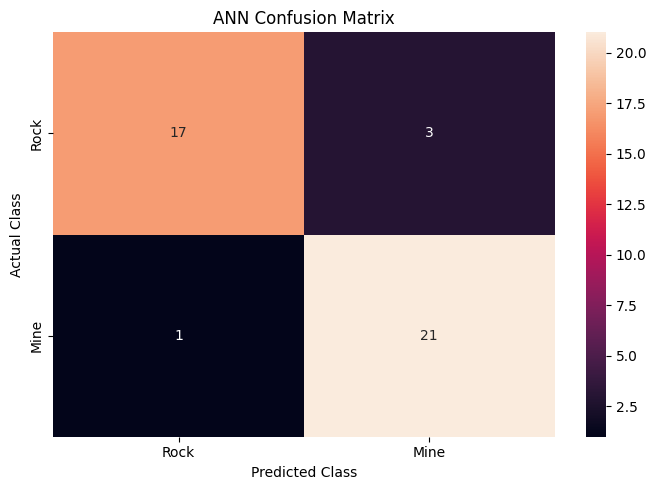

In [36]:
# Visualize the confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Rock', 'Mine'],
    yticklabels=['Rock', 'Mine']
)

plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()

In [37]:
# Display precision, recall and F1-score
# for the basic ANN model

print(classification_report(
    y_test,
    y_pred,
    target_names=['Rock', 'Mine']
))

              precision    recall  f1-score   support

        Rock       0.94      0.85      0.89        20
        Mine       0.88      0.95      0.91        22

    accuracy                           0.90        42
   macro avg       0.91      0.90      0.90        42
weighted avg       0.91      0.90      0.90        42



# Hyperparameter Tuning

In [38]:
# X_train and y_train were created in Task 2
# X_test and y_test will be used only for the final evaluation

# Create a validation set from the training data
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Display the shapes of the datasets
print("Subtraining data shape:", X_subtrain.shape)
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test_scaled.shape)

Subtraining data shape: (132, 60)
Validation data shape: (34, 60)
Test data shape: (42, 60)


In [39]:
# Define the number of hidden layers to test
hidden_layer_options = [1, 2]

# Define the number of neurons for a single hidden layer
neuron_options = [16, 32, 64]

# Define activation functions to test
activation_options = ['relu', 'tanh']

# Define learning rates to test
learning_rate_options = [0.001, 0.01]

# Display the hyperparameter options
print("Hidden layers:", hidden_layer_options)
print("Neurons:", neuron_options)
print("Activation functions:", activation_options)
print("Learning rates:", learning_rate_options)

Hidden layers: [1, 2]
Neurons: [16, 32, 64]
Activation functions: ['relu', 'tanh']
Learning rates: [0.001, 0.01]


In [40]:
# Create a function for constructing the neural network
def build_model(hidden_layers, neurons, activation, learning_rate):

    # Create a Sequential neural network
    model = Sequential()

    # Add the first hidden layer
    # The input contains 60 sonar features
    model.add(
        Dense(
            neurons,
            activation=activation,
            input_shape=(60,)
        )
    )

    # Check whether a second hidden layer is required
    if hidden_layers == 2:

        # Add the second hidden layer
        # Half of the neurons are used in the second layer
        model.add(
            Dense(
                neurons // 2,
                activation=activation
            )
        )

    # Add the output layer
    # Sigmoid produces a probability between 0 and 1
    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    # Create the Adam optimizer with the selected learning rate
    optimizer = Adam(learning_rate=learning_rate)

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Return the compiled model
    return model

In [41]:
# Create an empty list to store the results
results = []

# Counter to keep track of the models tested
model_number = 1

# Loop through the number of hidden layers
for hidden_layers in hidden_layer_options:

    # Loop through the number of neurons
    for neurons in neuron_options:

        # Loop through the activation functions
        for activation in activation_options:

            # Loop through the learning rates
            for learning_rate in learning_rate_options:

                print("\nTesting Model:", model_number)

                print("Hidden layers:", hidden_layers)
                print("Neurons:", neurons)
                print("Activation:", activation)
                print("Learning rate:", learning_rate)

                # Build the neural network using the current parameters
                model = build_model(
                    hidden_layers=hidden_layers,
                    neurons=neurons,
                    activation=activation,
                    learning_rate=learning_rate
                )

                # Train the model using the subtraining data
                history = model.fit(
                    X_subtrain,
                    y_subtrain,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_val, y_val),
                    verbose=0
                )

                # Evaluate the model on the validation data
                val_loss, val_accuracy = model.evaluate(
                    X_val,
                    y_val,
                    verbose=0
                )

                # Store the current model results
                results.append({
                    'Model': model_number,
                    'Hidden Layers': hidden_layers,
                    'Neurons': neurons,
                    'Activation': activation,
                    'Learning Rate': learning_rate,
                    'Validation Loss': val_loss,
                    'Validation Accuracy': val_accuracy
                })

                # Increase the model counter
                model_number += 1


Testing Model: 1
Hidden layers: 1
Neurons: 16
Activation: relu
Learning rate: 0.001


C:\Users\BALAJI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Testing Model: 2
Hidden layers: 1
Neurons: 16
Activation: relu
Learning rate: 0.01

Testing Model: 3
Hidden layers: 1
Neurons: 16
Activation: tanh
Learning rate: 0.001

Testing Model: 4
Hidden layers: 1
Neurons: 16
Activation: tanh
Learning rate: 0.01

Testing Model: 5
Hidden layers: 1
Neurons: 32
Activation: relu
Learning rate: 0.001

Testing Model: 6
Hidden layers: 1
Neurons: 32
Activation: relu
Learning rate: 0.01

Testing Model: 7
Hidden layers: 1
Neurons: 32
Activation: tanh
Learning rate: 0.001

Testing Model: 8
Hidden layers: 1
Neurons: 32
Activation: tanh
Learning rate: 0.01

Testing Model: 9
Hidden layers: 1
Neurons: 64
Activation: relu
Learning rate: 0.001

Testing Model: 10
Hidden layers: 1
Neurons: 64
Activation: relu
Learning rate: 0.01

Testing Model: 11
Hidden layers: 1
Neurons: 64
Activation: tanh
Learning rate: 0.001

Testing Model: 12
Hidden layers: 1
Neurons: 64
Activation: tanh
Learning rate: 0.01

Testing Model: 13
Hidden layers: 2
Neurons: 16
Activation: relu
Lea

In [44]:
# Convert the results list into a Pandas DataFrame
results_df = pd.DataFrame(results)

# Display all hyperparameter tuning results
results_df

,Model,Hidden Layers,Neurons,Activation,Learning Rate,Validation Loss,Validation Accuracy
0,1,1,16,relu,0.001,0.391759,0.794118
1,2,1,16,relu,0.010,0.442636,0.794118
2,3,1,16,tanh,0.001,0.423602,0.794118
3,4,1,16,tanh,0.010,0.574975,0.794118
4,5,1,32,relu,0.001,0.350054,0.882353
5,6,1,32,relu,0.010,0.482376,0.823529
6,7,1,32,tanh,0.001,0.398113,0.823529
7,8,1,32,tanh,0.010,0.595255,0.794118
8,9,1,64,relu,0.001,0.429430,0.735294
9,10,1,64,relu,0.010,0.352886,0.823529


In [43]:
# Sort the models from highest validation accuracy to lowest
results_sorted = results_df.sort_values(
    by='Validation Accuracy',
    ascending=False
)

# Display the sorted results
results_sorted

,Model,Hidden Layers,Neurons,Activation,Learning Rate,Validation Loss,Validation Accuracy
4,5,1,32,relu,0.001,0.350054,0.882353
12,13,2,16,relu,0.001,0.327953,0.852941
20,21,2,64,relu,0.001,0.441136,0.852941
5,6,1,32,relu,0.010,0.482376,0.823529
9,10,1,64,relu,0.010,0.352886,0.823529
13,14,2,16,relu,0.010,0.544679,0.823529
6,7,1,32,tanh,0.001,0.398113,0.823529
17,18,2,32,relu,0.010,0.614568,0.823529
21,22,2,64,relu,0.010,0.525386,0.823529
7,8,1,32,tanh,0.010,0.595255,0.794118


In [45]:
# Select the row containing the highest validation accuracy
best_result = results_sorted.iloc[0]

# Display the best hyperparameter configuration
print("Best Hyperparameter Configuration")
print("----------------------------------")
print("Hidden Layers:", best_result['Hidden Layers'])
print("Neurons:", best_result['Neurons'])
print("Activation:", best_result['Activation'])
print("Learning Rate:", best_result['Learning Rate'])
print("Validation Loss:", best_result['Validation Loss'])
print("Validation Accuracy:", best_result['Validation Accuracy'])

Best Hyperparameter Configuration
----------------------------------
Hidden Layers: 1
Neurons: 32
Activation: relu
Learning Rate: 0.001
Validation Loss: 0.35005417466163635
Validation Accuracy: 0.8823529481887817


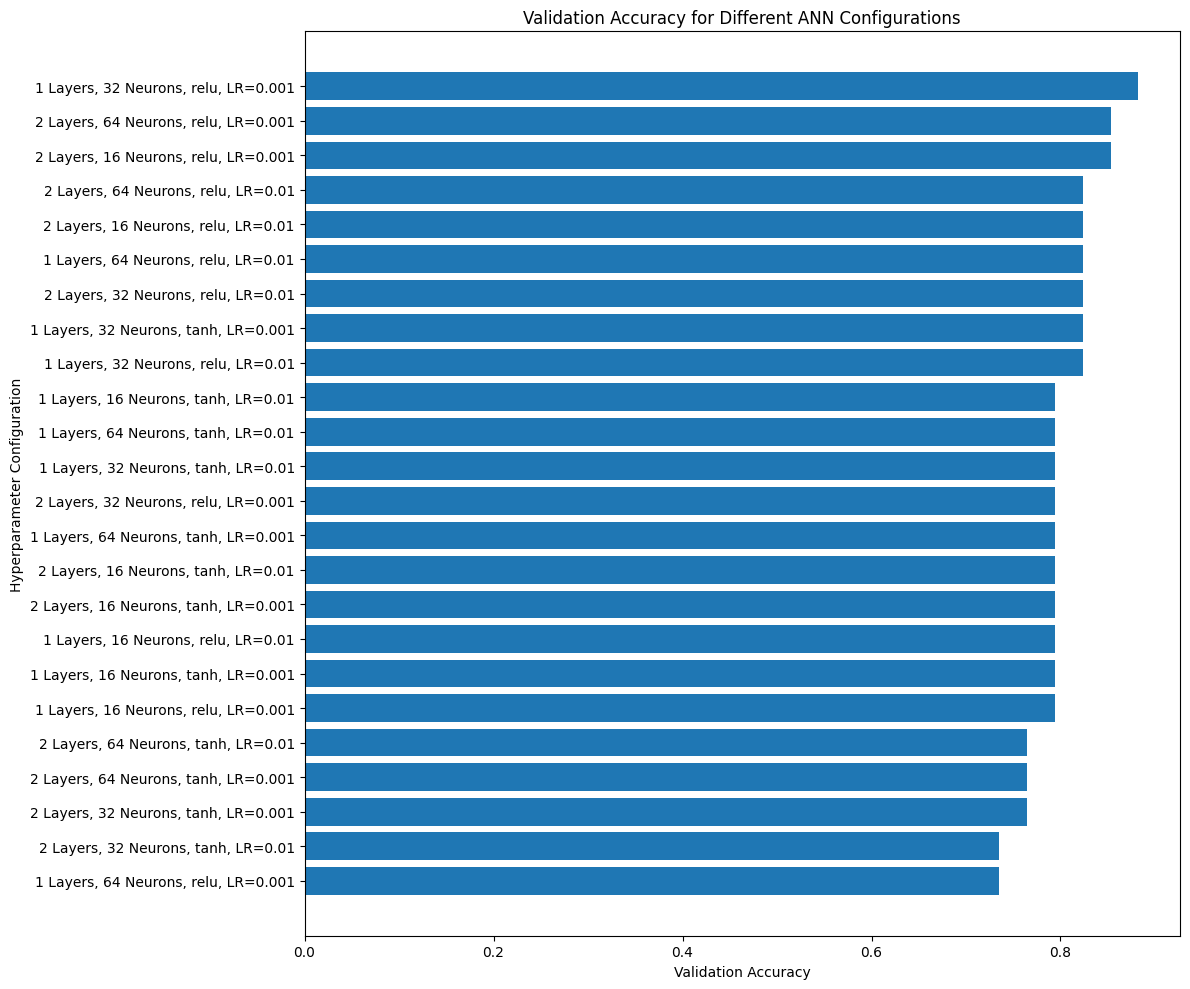

In [46]:
# Create a copy of the results
plot_data = results_df.copy()

# Create a label describing each model configuration
plot_data['Configuration'] = (
    plot_data['Hidden Layers'].astype(str) + ' Layers, ' +
    plot_data['Neurons'].astype(str) + ' Neurons, ' +
    plot_data['Activation'] + ', LR=' +
    plot_data['Learning Rate'].astype(str)
)

# Sort the configurations according to validation accuracy
plot_data = plot_data.sort_values(
    by='Validation Accuracy',
    ascending=True
)

# Plot validation accuracy
plt.figure(figsize=(12, 10))

plt.barh(
    plot_data['Configuration'],
    plot_data['Validation Accuracy']
)

plt.xlabel('Validation Accuracy')
plt.ylabel('Hyperparameter Configuration')
plt.title('Validation Accuracy for Different ANN Configurations')

plt.tight_layout()
plt.show()

In [47]:
# Calculate the average validation accuracy for each number of hidden layers
layer_analysis = results_df.groupby(
    'Hidden Layers'
)['Validation Accuracy'].mean()

# Display the average accuracy
print(layer_analysis)

Hidden Layers
1    0.803922
2    0.799020
Name: Validation Accuracy, dtype: float64


In [48]:
# Calculate average validation accuracy for each neuron configuration
neuron_analysis = results_df.groupby(
    'Neurons'
)['Validation Accuracy'].mean()

# Display the results
print(neuron_analysis)

Neurons
16    0.805147
32    0.805147
64    0.794118
Name: Validation Accuracy, dtype: float64


In [49]:
# Calculate average validation accuracy for each activation function
activation_analysis = results_df.groupby(
    'Activation'
)['Validation Accuracy'].mean()

# Display the results
print(activation_analysis)

Activation
relu    0.818627
tanh    0.784314
Name: Validation Accuracy, dtype: float64


In [50]:
# Calculate average validation accuracy for each learning rate
learning_rate_analysis = results_df.groupby(
    'Learning Rate'
)['Validation Accuracy'].mean()

# Display the results
print(learning_rate_analysis)

Learning Rate
0.001    0.803922
0.010    0.799020
Name: Validation Accuracy, dtype: float64


In [51]:
# Extract the best hyperparameters
best_hidden_layers = int(best_result['Hidden Layers'])
best_neurons = int(best_result['Neurons'])
best_activation = best_result['Activation']
best_learning_rate = float(best_result['Learning Rate'])

# Build the best model using the selected hyperparameters
tuned_model = build_model(
    hidden_layers=best_hidden_layers,
    neurons=best_neurons,
    activation=best_activation,
    learning_rate=best_learning_rate
)

# Display the tuned model architecture
tuned_model.summary()

C:\Users\BALAJI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                     │ (None, 32)                  │           1,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Train the tuned model using all training data
tuned_history = tuned_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.4924 - loss: 0.7924 - val_accuracy: 0.7941 - val_loss: 0.5322
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6288 - loss: 0.6734 - val_accuracy: 0.8529 - val_loss: 0.5003
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7045 - loss: 0.6070 - val_accuracy: 0.8529 - val_loss: 0.4757
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7348 - loss: 0.5615 - val_accuracy: 0.9118 - val_loss: 0.4549
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7576 - loss: 0.5274 - val_accuracy: 0.9118 - val_loss: 0.4399
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7803 - loss: 0.4965 - val_accuracy: 0.9118 - val_loss: 0.4252
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8030 - loss: 0.4719 - val_accuracy: 0.9118 - val_loss: 0.4123
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8106 - loss: 0.4474 - val_accuracy: 0.9118 - val_loss: 0.4008


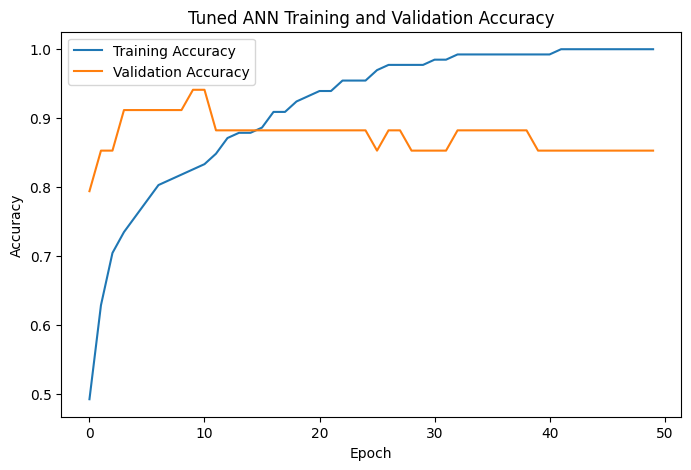

In [53]:
# Create a figure for training and validation accuracy
plt.figure(figsize=(8, 5))

# Plot training accuracy
plt.plot(
    tuned_history.history['accuracy'],
    label='Training Accuracy'
)

# Plot validation accuracy
plt.plot(
    tuned_history.history['val_accuracy'],
    label='Validation Accuracy'
)

# Add graph details
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Tuned ANN Training and Validation Accuracy')
plt.legend()

plt.show()

In [54]:
# Create a DataFrame containing the selected hyperparameters
best_parameters = pd.DataFrame({
    'Parameter': [
        'Hidden Layers',
        'Neurons',
        'Activation Function',
        'Learning Rate',
        'Epochs',
        'Batch Size'
    ],
    'Selected Value': [
        best_hidden_layers,
        best_neurons,
        best_activation,
        best_learning_rate,
        50,
        16
    ]
})

# Display the selected hyperparameters
best_parameters

,Parameter,Selected Value
0,Hidden Layers,1
1,Neurons,32
2,Activation Function,relu
3,Learning Rate,0.001
4,Epochs,50
5,Batch Size,16


# Evaluation

In [56]:
# Generate prediction probabilities using the default ANN
default_probability = model.predict(X_test_scaled)

# Convert probabilities into class labels
# A probability greater than or equal to 0.5 is classified as Mine
# A probability below 0.5 is classified as Rock
default_prediction = (
    default_probability >= 0.5
).astype(int).ravel()

# Display the first few predictions
print("Default Model Predictions:")
print(default_prediction[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Default Model Predictions:
[0 1 1 1 0 1 0 1 0 0]


In [57]:
# Calculate accuracy of the default model
default_accuracy = accuracy_score(
    y_test,
    default_prediction
)

# Calculate precision of the default model
default_precision = precision_score(
    y_test,
    default_prediction
)

# Calculate recall of the default model
default_recall = recall_score(
    y_test,
    default_prediction
)

# Calculate F1 score of the default model
default_f1 = f1_score(
    y_test,
    default_prediction
)

# Display the evaluation metrics
print("Default ANN Model Performance")
print("Accuracy :", default_accuracy)
print("Precision:", default_precision)
print("Recall   :", default_recall)
print("F1 Score :", default_f1)

Default ANN Model Performance
Accuracy : 0.8571428571428571
Precision: 0.8636363636363636
Recall   : 0.8636363636363636
F1 Score : 0.8636363636363636


In [58]:
# Generate a detailed classification report
print("Classification Report for Default ANN")
print(
    classification_report(
        y_test,
        default_prediction,
        target_names=['Rock', 'Mine']
    )
)

Classification Report for Default ANN
              precision    recall  f1-score   support

        Rock       0.85      0.85      0.85        20
        Mine       0.86      0.86      0.86        22

    accuracy                           0.86        42
   macro avg       0.86      0.86      0.86        42
weighted avg       0.86      0.86      0.86        42



In [59]:
# Calculate the confusion matrix
default_cm = confusion_matrix(
    y_test,
    default_prediction
)

# Display the numerical confusion matrix
print("Default Model Confusion Matrix:")
print(default_cm)

Default Model Confusion Matrix:
[[17  3]
 [ 3 19]]


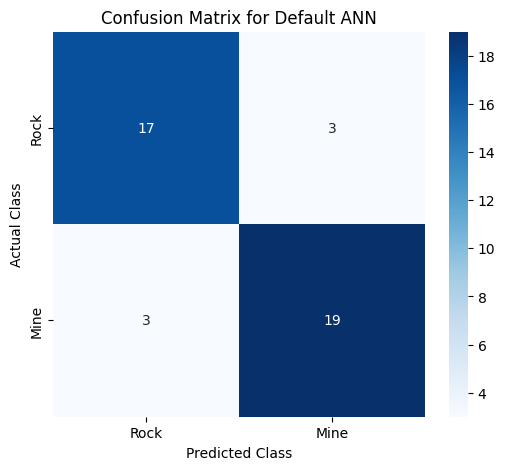

In [60]:
# Create a figure for the confusion matrix
plt.figure(figsize=(6, 5))

# Create the heatmap
sns.heatmap(
    default_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rock', 'Mine'],
    yticklabels=['Rock', 'Mine']
)

# Add labels to the axes
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Add the title
plt.title('Confusion Matrix for Default ANN')

# Display the graph
plt.show()

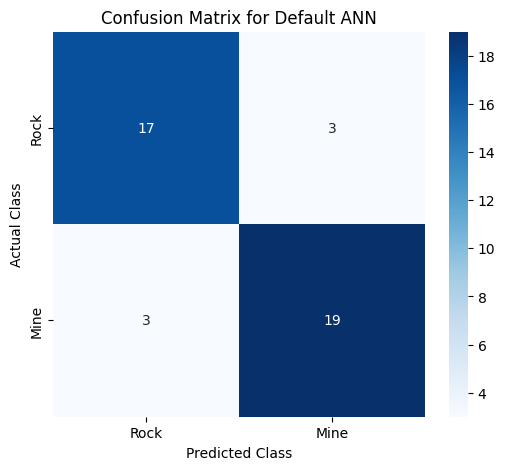

In [61]:
# Create a figure for the confusion matrix
plt.figure(figsize=(6, 5))

# Create the heatmap
sns.heatmap(
    default_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rock', 'Mine'],
    yticklabels=['Rock', 'Mine']
)

# Add labels to the axes
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Add the title
plt.title('Confusion Matrix for Default ANN')

# Display the graph
plt.show()

In [62]:
# Generate prediction probabilities using the tuned ANN
tuned_probability = tuned_model.predict(X_test_scaled)

# Convert probabilities into binary class predictions
tuned_prediction = (
    tuned_probability >= 0.5
).astype(int).ravel()

# Display the first few predictions
print("Tuned Model Predictions:")
print(tuned_prediction[:10])

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001D4CECE6170> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Tuned Model Predictions:
[0 1 1 1 0 1 0 1 0 0]


In [63]:
# Calculate accuracy of the tuned model
tuned_accuracy = accuracy_score(
    y_test,
    tuned_prediction
)

# Calculate precision of the tuned model
tuned_precision = precision_score(
    y_test,
    tuned_prediction
)

# Calculate recall of the tuned model
tuned_recall = recall_score(
    y_test,
    tuned_prediction
)

# Calculate F1 score of the tuned model
tuned_f1 = f1_score(
    y_test,
    tuned_prediction
)

# Display the evaluation metrics
print("Tuned ANN Model Performance")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

Tuned ANN Model Performance
Accuracy : 0.9285714285714286
Precision: 0.9130434782608695
Recall   : 0.9545454545454546
F1 Score : 0.9333333333333333


In [64]:
# Generate a detailed classification report for the tuned model
print("Classification Report for Tuned ANN")
print(
    classification_report(
        y_test,
        tuned_prediction,
        target_names=['Rock', 'Mine']
    )
)

Classification Report for Tuned ANN
              precision    recall  f1-score   support

        Rock       0.95      0.90      0.92        20
        Mine       0.91      0.95      0.93        22

    accuracy                           0.93        42
   macro avg       0.93      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



In [65]:
# Calculate the confusion matrix for the tuned model
tuned_cm = confusion_matrix(
    y_test,
    tuned_prediction
)

# Display the numerical confusion matrix
print("Tuned Model Confusion Matrix:")
print(tuned_cm)

Tuned Model Confusion Matrix:
[[18  2]
 [ 1 21]]


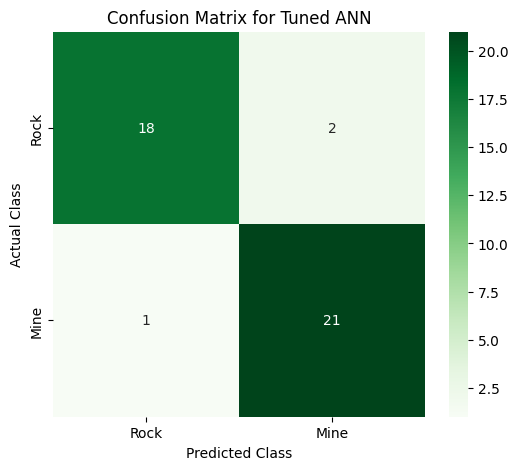

In [66]:
# Create a figure for the tuned model confusion matrix
plt.figure(figsize=(6, 5))

# Create the heatmap
sns.heatmap(
    tuned_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Rock', 'Mine'],
    yticklabels=['Rock', 'Mine']
)

# Add axis labels
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Add title
plt.title('Confusion Matrix for Tuned ANN')

# Display the graph
plt.show()

In [67]:
# Create a DataFrame containing the performance of both models
comparison_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    
    'Default ANN': [
        default_accuracy,
        default_precision,
        default_recall,
        default_f1
    ],
    
    'Tuned ANN': [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

# Display the comparison table
comparison_df

,Metric,Default ANN,Tuned ANN
0,Accuracy,0.857143,0.928571
1,Precision,0.863636,0.913043
2,Recall,0.863636,0.954545
3,F1 Score,0.863636,0.933333


In [68]:
# Create a DataFrame containing the performance of both models
comparison_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    
    'Default ANN': [
        default_accuracy,
        default_precision,
        default_recall,
        default_f1
    ],
    
    'Tuned ANN': [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

# Display the comparison table
comparison_df

,Metric,Default ANN,Tuned ANN
0,Accuracy,0.857143,0.928571
1,Precision,0.863636,0.913043
2,Recall,0.863636,0.954545
3,F1 Score,0.863636,0.933333


In [69]:
# Calculate the improvement in each evaluation metric
improvement = {
    'Accuracy Improvement': tuned_accuracy - default_accuracy,
    'Precision Improvement': tuned_precision - default_precision,
    'Recall Improvement': tuned_recall - default_recall,
    'F1 Improvement': tuned_f1 - default_f1
}

# Display the improvement values
for metric, value in improvement.items():
    print(metric, ":", value)

Accuracy Improvement : 0.07142857142857151
Precision Improvement : 0.049407114624505866
Recall Improvement : 0.09090909090909094
F1 Improvement : 0.0696969696969697


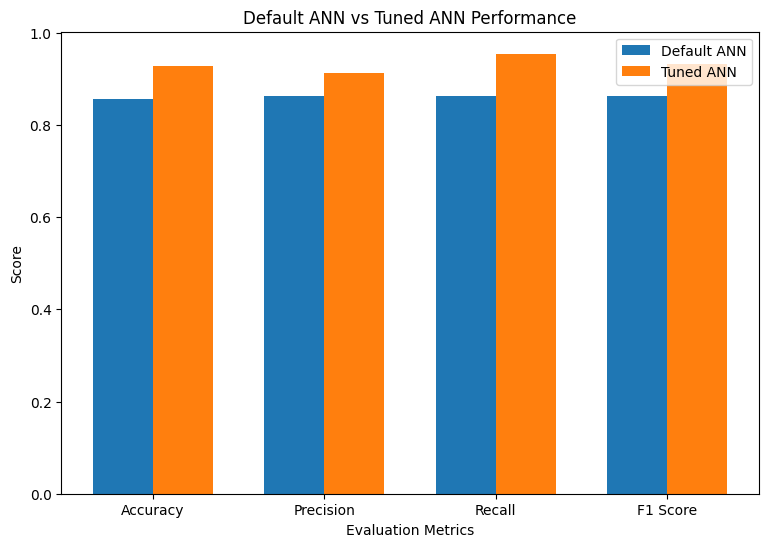

In [70]:
# Create metric names
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Store default model values
default_values = [
    default_accuracy,
    default_precision,
    default_recall,
    default_f1
]

# Store tuned model values
tuned_values = [
    tuned_accuracy,
    tuned_precision,
    tuned_recall,
    tuned_f1
]

# Create positions for the bars
x = np.arange(len(metrics))

# Define the width of each bar
width = 0.35

# Create the figure
plt.figure(figsize=(9, 6))

# Plot default model metrics
plt.bar(
    x - width / 2,
    default_values,
    width,
    label='Default ANN'
)

# Plot tuned model metrics
plt.bar(
    x + width / 2,
    tuned_values,
    width,
    label='Tuned ANN'
)

# Add metric names to the x axis
plt.xticks(
    x,
    metrics
)

# Add axis labels
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')

# Add title
plt.title('Default ANN vs Tuned ANN Performance')

# Add legend
plt.legend()

# Display the graph
plt.show()

In [71]:
# Display the default model configuration
print("Default ANN Configuration")
print("-------------------------")
print("Hidden Layers   : 1")
print("Neurons         : 32")
print("Activation      : ReLU")
print("Learning Rate   : Adam default")
print("Epochs          : 50")
print("Batch Size      : 16")

# Display the tuned model configuration
print("\nTuned ANN Configuration")
print("-----------------------")
print("Hidden Layers   :", best_hidden_layers)
print("Neurons         :", best_neurons)
print("Activation      :", best_activation)
print("Learning Rate   :", best_learning_rate)
print("Epochs          : 50")
print("Batch Size      : 16")

Default ANN Configuration
-------------------------
Hidden Layers   : 1
Neurons         : 32
Activation      : ReLU
Learning Rate   : Adam default
Epochs          : 50
Batch Size      : 16

Tuned ANN Configuration
-----------------------
Hidden Layers   : 1
Neurons         : 32
Activation      : relu
Learning Rate   : 0.001
Epochs          : 50
Batch Size      : 16


#### Discuss the performance differences between the model with default hyperparameters and the tuned model, emphasizing the effects of hyperparameter tuning.


The default ANN model was initially evaluated using the unseen test dataset. Accuracy, precision, recall, and F1 score were calculated to establish the baseline performance. The tuned ANN was then evaluated using exactly the same test dataset. The tuned model was selected through the structured grid search performed in Task 3, where different hidden layer configurations, neuron counts, activation functions, and learning rates were tested.

The comparison of the two models shows how hyperparameter selection affected classification performance. Changes in the number of hidden layers and neurons modified the learning capacity of the network, while the activation function affected the nonlinear representation learned by the hidden layers. The learning rate controlled the size of the weight updates during optimization.

If the tuned model has higher test accuracy, precision, recall, and F1 score than the default model, this indicates that the selected hyperparameters improved the model's performance on the unseen test data. If some metrics increased while others decreased, the tuning produced a tradeoff between different aspects of classification performance. Therefore, the effect of hyperparameter tuning should be discussed using all four evaluation metrics rather than accuracy alone.